<a href="https://colab.research.google.com/github/mdzubayereashraf/Ostad-AI-Engineering-Course-Assignments/blob/main/Assignmen_No_14(Deep_Learning_Project_Dog_vs_Cat_Image_Classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Module 14 Project: Dog vs Cat Image Classification**

## **Objective:**

The goal of this project is to build and evaluate deep learning models
for binary image classification of dogs and cats.

Three different approaches will be compared:

1. Custom CNN
2. Transfer Learning using MobileNetV2 (Feature Extraction)
3. Transfer Learning using EfficientNetB0 (Full Fine-Tuning)

The models will be evaluated using accuracy, precision, recall, F1-score,
loss, confusion matrix, and error analysis.

# **Question 1 : Dataset Preparation**

### **Download The Dataset**

In [66]:
!git clone https://github.com/laxmimerit/dog-cat-full-dataset.git

fatal: destination path 'dog-cat-full-dataset' already exists and is not an empty directory.


### **Import all required libraries**

In [67]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)


### **Load the datasets**

In [68]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dir = "/content/dog-cat-full-dataset/data/train"
test_dir = "/content/dog-cat-full-dataset/data/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("Class names:", class_names)

Found 19989 files belonging to 2 classes.
Using 15992 files for training.
Found 19989 files belonging to 2 classes.
Using 3997 files for validation.
Found 5000 files belonging to 2 classes.
Class names: ['cats', 'dogs']


### **Number of samples**

In [69]:
train_samples = len(train_ds.file_paths)
val_samples = len(val_ds.file_paths)
test_samples = len(test_ds.file_paths)

print("Training samples:", train_samples)
print("Validation samples:", val_samples)
print("Test samples:", test_samples)

Training samples: 15992
Validation samples: 3997
Test samples: 5000


### **Normalize**

In [70]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

### **Prefetch**

In [71]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# **Question 2 : Data Augmentation**

In [72]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

### **Original + 4 augmented images**

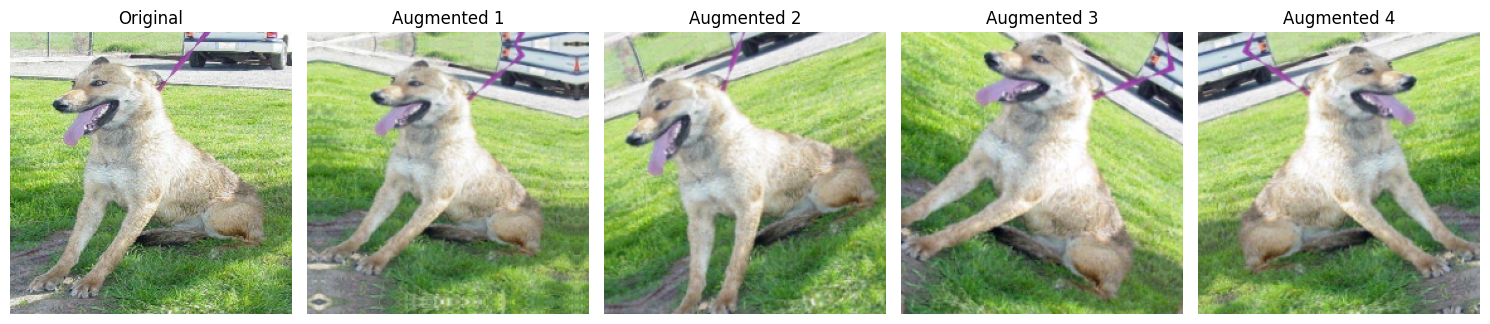

In [73]:
for images, labels in train_ds.take(1):
    original_image = images[0]
    break

plt.figure(figsize=(15, 6))

plt.subplot(1, 5, 1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

for i in range(4):
    augmented_image = data_augmentation(
        tf.expand_dims(original_image, 0),
        training=True
    )[0]

    plt.subplot(1, 5, i + 2)
    plt.imshow(augmented_image)
    plt.title(f"Augmented {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Question 3 : Custom CNN**

In [74]:
custom_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

custom_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,497 (42.61 MB)

 Trainable params: 11,169,793 (42.61 MB)

 Non-trainable params: 704 (2.75 KB)

### **Compile**

In [75]:
custom_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### **Early stopping**

In [76]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

### **Train**

In [77]:
custom_history = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 133ms/step - accuracy: 0.6643 - loss: 0.6672 - val_accuracy: 0.5672 - val_loss: 0.9305
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 135ms/step - accuracy: 0.7462 - loss: 0.5132 - val_accuracy: 0.7621 - val_loss: 0.4973
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 133ms/step - accuracy: 0.7814 - loss: 0.4617 - val_accuracy: 0.7686 - val_loss: 0.4960
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 132ms/step - accuracy: 0.8017 - loss: 0.4311 - val_accuracy: 0.8119 - val_loss: 0.4256
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 133ms/step - accuracy: 0.8188 - loss: 0.4012 - val_accuracy: 0.8179 - val_loss: 0.4095
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 135ms/step - accuracy: 0.8391 - loss: 0.3657 - val_accuracy: 0.8516 - val_loss: 0.3465
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 133ms/step - accuracy: 0.8525 - loss: 0.3393 - val_accuracy: 0.7843 - val_loss: 0.4942
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 133ms/step - accuracy: 0.8618 - loss: 0

### **Training Accuracy Plot**

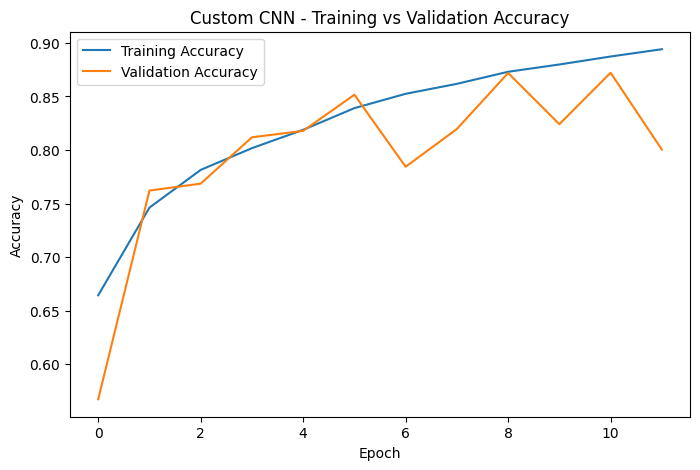

In [78]:
plt.figure(figsize=(8, 5))

plt.plot(
    custom_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    custom_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN - Training vs Validation Accuracy")
plt.legend()
plt.show()

### **Loss Plot**

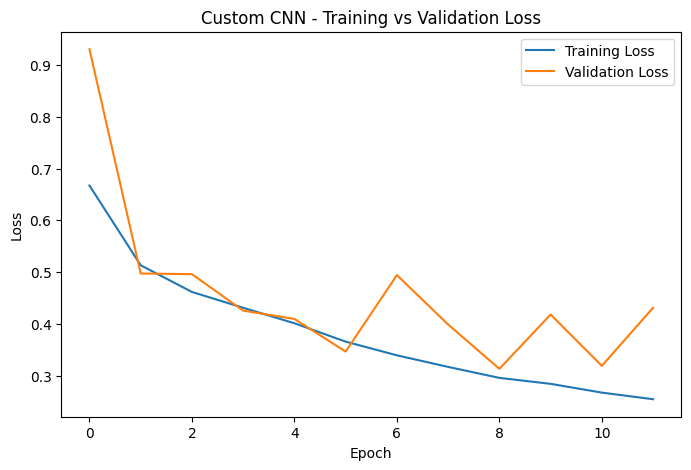

In [79]:
plt.figure(figsize=(8, 5))

plt.plot(
    custom_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    custom_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN - Training vs Validation Loss")
plt.legend()
plt.show()

# **Question 4 : MobileNetV2 Feature Extraction**

In [80]:
mobilenet_base = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

mobilenet_base.trainable = False

### **Model**

In [81]:
mobilenet_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Convert [0,1] images to [-1,1] for MobileNetV2
    tf.keras.layers.Rescaling(2.0, offset=-1.0),

    mobilenet_base,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

mobilenet_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_11 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### **Compile**

In [82]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### **Train**

In [83]:
early_stopping_mobilenet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping_mobilenet]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 46s 75ms/step - accuracy: 0.9808 - loss: 0.0658 - val_accuracy: 0.9865 - val_loss: 0.0436
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.9877 - loss: 0.0363 - val_accuracy: 0.9857 - val_loss: 0.0429
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.9891 - loss: 0.0328 - val_accuracy: 0.9865 - val_loss: 0.0445
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.9892 - loss: 0.0304 - val_accuracy: 0.9862 - val_loss: 0.0418
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.9904 - loss: 0.0269 - val_accuracy: 0.9862 - val_loss: 0.0424
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.9910 - loss: 0.0270 - val_accuracy: 0.9862 - val_loss: 0.0439
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.9909 - loss: 0.0256 - val_accuracy: 0.9857 - val_loss: 0.0418
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.9909 - loss: 0.0256 - 

### **Accuracy**

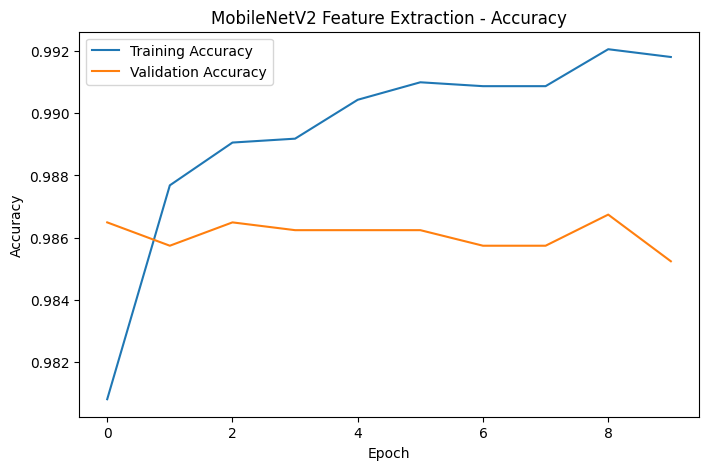

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    mobilenet_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Feature Extraction - Accuracy")
plt.legend()
plt.show()

### **Loss**

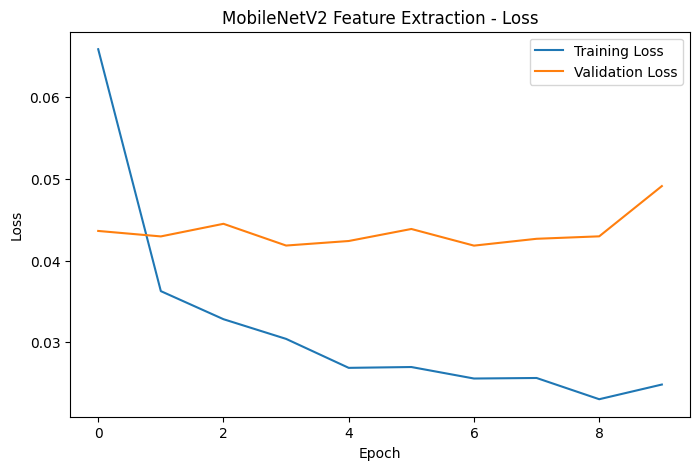

In [85]:
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    mobilenet_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Feature Extraction - Loss")
plt.legend()
plt.show()

# **Question 5 : Full Fine-Tuning with EfficientNetB0**

### **Model**

In [86]:
efficientnet_base = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

efficientnet_base.trainable = True

In [87]:
efficientnet_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Dataset is normalized to [0,1], so convert back to [0,255]
    tf.keras.layers.Rescaling(255.0),

    efficientnet_base,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

efficientnet_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_14 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 4,008,829 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

### **Compile**

In [88]:
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### **Early stopping**

In [89]:
early_stopping_efficientnet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

### **Train**

In [90]:
efficientnet_history = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping_efficientnet]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 184s 234ms/step - accuracy: 0.8893 - loss: 0.3301 - val_accuracy: 0.9725 - val_loss: 0.1213
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 142ms/step - accuracy: 0.9677 - loss: 0.1126 - val_accuracy: 0.9835 - val_loss: 0.0633
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 144ms/step - accuracy: 0.9793 - loss: 0.0668 - val_accuracy: 0.9855 - val_loss: 0.0454
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 141ms/step - accuracy: 0.9814 - loss: 0.0533 - val_accuracy: 0.9870 - val_loss: 0.0372
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 151ms/step - accuracy: 0.9856 - loss: 0.0422 - val_accuracy: 0.9875 - val_loss: 0.0326
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 141ms/step - accuracy: 0.9893 - loss: 0.0336 - val_accuracy: 0.9895 - val_loss: 0.0299
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 151ms/step - accuracy: 0.9907 - loss: 0.0289 - val_accuracy: 0.9897 - val_loss: 0.0280
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 151ms/step - accuracy: 0.9916 - loss: 

### **Accuracy**

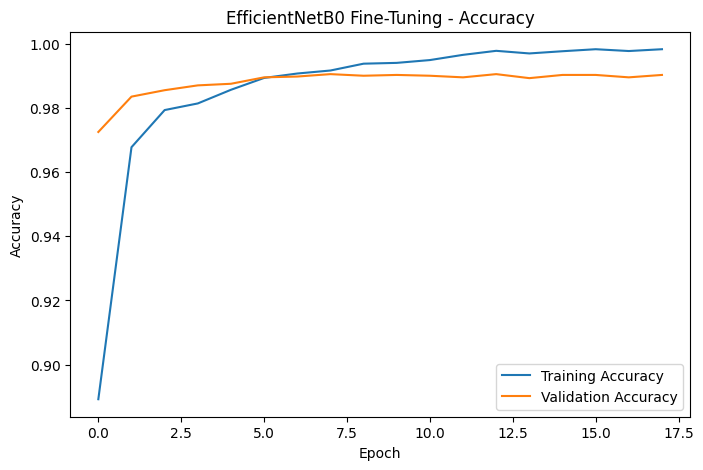

In [98]:
plt.figure(figsize=(8, 5))

plt.plot(
    efficientnet_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    efficientnet_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 Fine-Tuning - Accuracy")
plt.legend()
plt.show()

### **Loss**

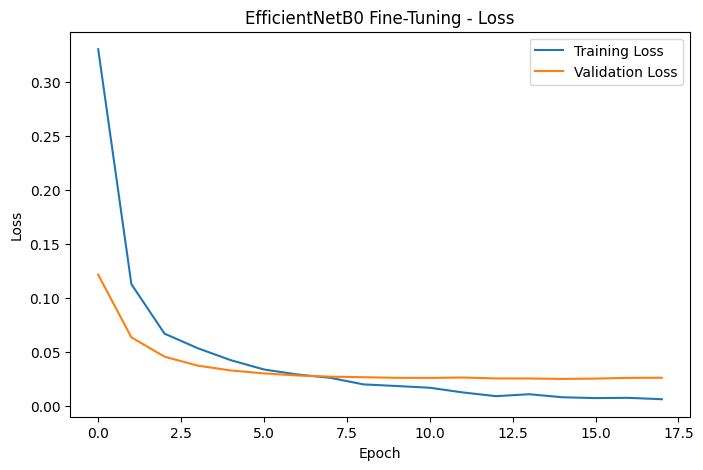

In [97]:
plt.figure(figsize=(8, 5))

plt.plot(
    efficientnet_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    efficientnet_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Fine-Tuning - Loss")
plt.legend()
plt.show()

# **Question 6 : Model Comparison**

In [96]:
def evaluate_model(model, dataset):
    loss, accuracy = model.evaluate(dataset, verbose=0)

    y_true = []
    y_prob = []

    for images, labels in dataset:
        probabilities = model.predict(images, verbose=0).ravel()

        y_true.extend(labels.numpy())
        y_prob.extend(probabilities)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    y_pred = (y_prob >= 0.5).astype(int)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return loss, accuracy, precision, recall, f1

### **Evaluate three models**

In [95]:
custom_test = evaluate_model(custom_model, test_ds)
mobilenet_test = evaluate_model(mobilenet_model, test_ds)
efficientnet_test = evaluate_model(efficientnet_model, test_ds)

print("Custom CNN:", custom_test)
print("MobileNetV2:", mobilenet_test)
print("EfficientNetB0:", efficientnet_test)

Custom CNN: (0.31522491574287415, 0.864799976348877, 0.8494252873563218, 0.8868, 0.8677103718199609)
MobileNetV2: (0.033550918102264404, 0.9891999959945679, 0.9876395534290271, 0.9908, 0.9892172523961661)
EfficientNetB0: (0.021955003961920738, 0.9944000244140625, 0.9940047961630696, 0.9948, 0.9944022391043582)


In [99]:
def get_train_val_metrics(history):
    return {
        "Training Loss": history.history["loss"][-1],
        "Training Accuracy": history.history["accuracy"][-1],
        "Validation Loss": history.history["val_loss"][-1],
        "Validation Accuracy": history.history["val_accuracy"][-1]
    }


custom_metrics = get_train_val_metrics(custom_history)
mobilenet_metrics = get_train_val_metrics(mobilenet_history)
efficientnet_metrics = get_train_val_metrics(efficientnet_history)

In [100]:
comparison = pd.DataFrame({
    "Custom CNN": [
        custom_model.count_params(),
        custom_metrics["Training Loss"],
        custom_metrics["Training Accuracy"],
        custom_metrics["Validation Loss"],
        custom_metrics["Validation Accuracy"],
        custom_test[0],
        custom_test[1],
        custom_test[2],
        custom_test[3],
        custom_test[4]
    ],

    "MobileNetV2 Feature Extraction": [
        mobilenet_model.count_params(),
        mobilenet_metrics["Training Loss"],
        mobilenet_metrics["Training Accuracy"],
        mobilenet_metrics["Validation Loss"],
        mobilenet_metrics["Validation Accuracy"],
        mobilenet_test[0],
        mobilenet_test[1],
        mobilenet_test[2],
        mobilenet_test[3],
        mobilenet_test[4]
    ],

    "EfficientNetB0 Fine-Tuning": [
        efficientnet_model.count_params(),
        efficientnet_metrics["Training Loss"],
        efficientnet_metrics["Training Accuracy"],
        efficientnet_metrics["Validation Loss"],
        efficientnet_metrics["Validation Accuracy"],
        efficientnet_test[0],
        efficientnet_test[1],
        efficientnet_test[2],
        efficientnet_test[3],
        efficientnet_test[4]
    ]
}, index=[
    "Total Parameters",
    "Training Loss",
    "Training Accuracy",
    "Validation Loss",
    "Validation Accuracy",
    "Test Loss",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1 Score"
])

comparison.round(4)

,Custom CNN,MobileNetV2 Feature Extraction,EfficientNetB0 Fine-Tuning
Total Parameters,1.117050e+07,2.259265e+06,4.050852e+06
Training Loss,2.545000e-01,2.480000e-02,6.000000e-03
Training Accuracy,8.941000e-01,9.918000e-01,9.982000e-01
Validation Loss,4.312000e-01,4.910000e-02,2.590000e-02
Validation Accuracy,8.004000e-01,9.852000e-01,9.902000e-01
Test Loss,3.152000e-01,3.360000e-02,2.200000e-02
Test Accuracy,8.648000e-01,9.892000e-01,9.944000e-01
Test Precision,8.494000e-01,9.876000e-01,9.940000e-01
Test Recall,8.868000e-01,9.908000e-01,9.948000e-01
Test F1 Score,8.677000e-01,9.892000e-01,9.944000e-01


## Model Comparison Discussion

The three models were evaluated using training loss, training accuracy,
validation loss, validation accuracy, test loss, test accuracy,
precision, recall, and F1-score.

### Best Performing Model

EfficientNetB0 with full fine-tuning performed the best overall.

It achieved a test accuracy of approximately **99.44%** and an F1-score
of approximately **99.44%**. It also achieved a very low test loss of
approximately **0.022**.

Therefore, EfficientNetB0 was the best-performing model among the three
models.

### Most Computationally Efficient Model

The Custom CNN has the highest number of parameters among the three
models in this experiment. The MobileNetV2 feature extraction model has
fewer parameters and only its classification head is trained, making it
more computationally efficient during training.

Feature extraction is generally faster because the pretrained backbone
is frozen and its weights do not need to be updated.

### Production Deployment

For production deployment, MobileNetV2 Feature Extraction could be a
good choice when computational resources, training time, or model size
are important.

However, if maximum classification performance is the main priority,
EfficientNetB0 Fine-Tuning would be preferred because it achieved the
highest test accuracy and F1-score in this experiment.

Overall, the choice depends on the trade-off between accuracy,
computational cost, inference speed, and available hardware.

# **Question 7 : Error Analysis**